In [6]:
from experiment_functions import run_experiment, plot_experiment, PERTURBATION_TYPES
from pathlib import Path
import numpy as np

In [ ]:
data_dir   = Path("../data/data_234")
file_paths = sorted(data_dir.glob("*.graphml"))[:100] # taking a subsample of 100 datapoints to reduce running time by 10
print(f"Found {len(file_paths)} connectome files")

dt    = 0.01
sigma = 10.0
rho   = 28.0
beta  = 8 / 3

Js = np.array([1.1,0.9,0.6])
J           = 0.9
input_scale = 0.5
lambda_reg  = 3e-6
seed_base   = 42
alpha       = 0.3

t_thermalization = 30.0
t_training       = 100.0 # dropped from 200 to decrease running time
t_prediction     = 50.0

p_values = [0.0, 0.05, 0.10, 0.25, 0.50]
n_runs   = 3       # inner expectation over runs per reservoir
epsilon  = 0.5     # t_div threshold

Found 100 connectome files


In [ ]:
# for j in Js: # run experiment for different Js
results = run_experiment(
    file_paths,
    p_values          = p_values,
    n_runs            = n_runs,
    epsilon           = epsilon,
    J                 = J,
    lambda_reg        = lambda_reg,
    t_thermalization  = t_thermalization,
    t_training        = t_training,
    t_prediction      = t_prediction,
    sigma             = sigma,
    rho               = rho,
    beta              = beta,
    dt                = dt,
    input_scale       = input_scale,
    seed_base         = seed_base,
    alpha             = alpha,
) 

In [9]:
# save raw results so the experiment does not need to be re-run

out = {}
for mode in PERTURBATION_TYPES:
    for p in p_values:
        out[f"{mode}__p{p:.2f}"] = np.array(results[mode][p])
# np.savez("results.npz", **out)
# print("Results saved to results.npz")

C:\Users\Anper\AppData\Local\Temp\ipykernel_13200\864561825.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


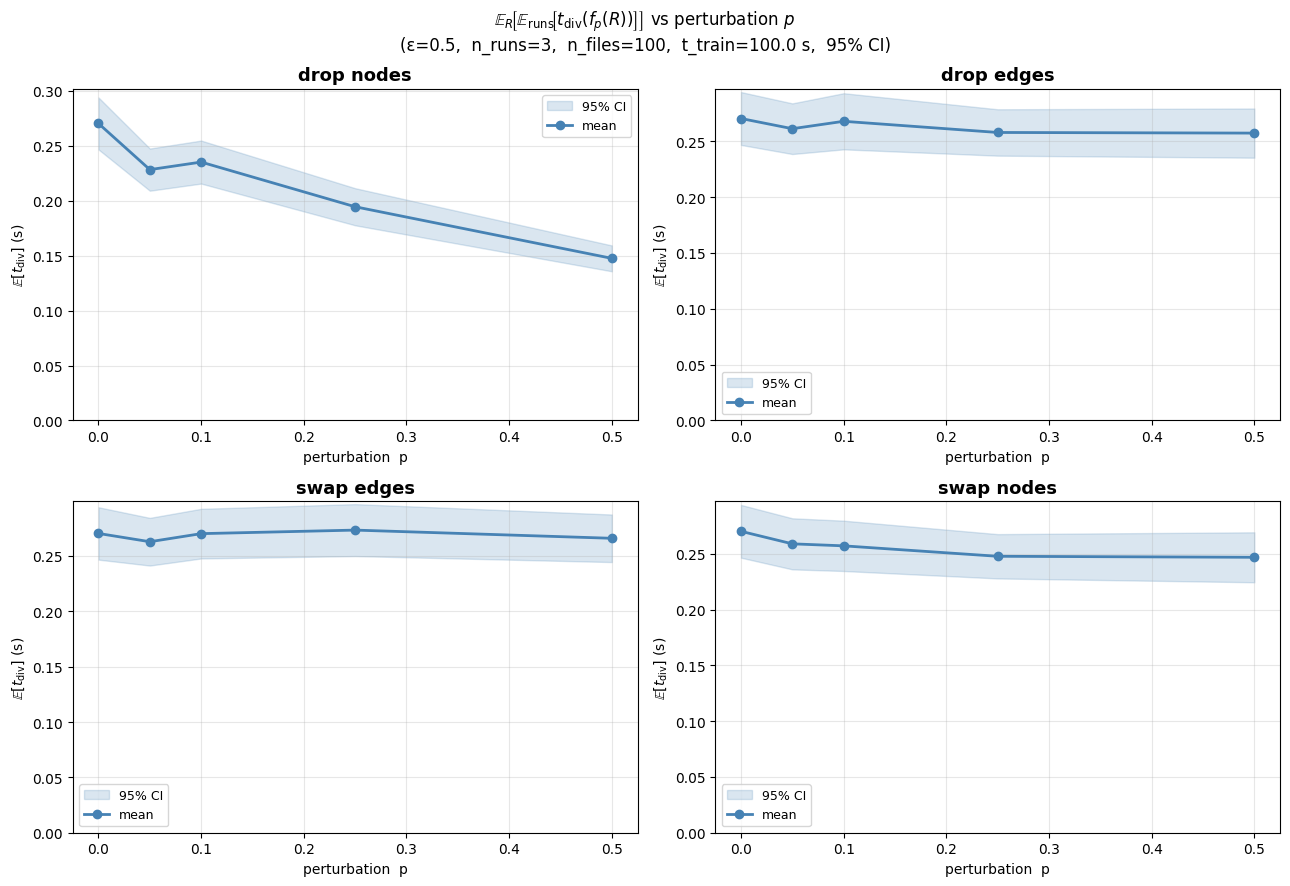

In [10]:
fig = plot_experiment(
    results,
    p_values   = p_values,
    epsilon    = epsilon,
    n_runs     = n_runs,
    n_files    = len(file_paths),
    t_training = t_training,
)
fig.show()